# Homework #4

## Regularization in Machine Learning

This colaboratory contains Homework #4 of the Machine Learning course. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.


## Submission's rules:

1.   Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

##List of Homework's exercises:

1.   [Ex1](#scrollTo=gCUvnKxZXTul) - 3 points
2.   [Ex2](#scrollTo=yLmunCZ9k-G6) - 4 points
3.   [Ex3](#scrollTo=lPdnuVSqeIN2) - 3 points
4.   [Bonus 1](#scrollTo=piaKpOh8If7h) - 2 points
5.   [Bonus 2](#scrollTo=jdZkblZW7bEp) - up to 4 points (based on quality of presentation)


In [1]:
!pip install -q plotnine
from plotnine import *

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

import matplotlib.pyplot as plt

# loading in the cifar10 dataset
from keras.datasets import cifar10
from keras.layers import Input, Conv2D, Activation, Flatten, Dense, MaxPooling2D, BatchNormalization, Dropout
from keras import regularizers, optimizers, Sequential

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
# Auxiliary functions
def plot_curves(history):
  plt.figure(figsize=(16, 6))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Training', 'Validation'])
  plt.title('Loss')

  plt.subplot(1, 2, 2)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Training', 'Validation'])
  plt.title('Accuracy')

def define_model(lambda_):
  model = Sequential()
  model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_), input_shape=(32, 32, 3)))
  model.add(Activation('relu'))
  model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))

  model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))

  model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))

  model.add(Flatten())

  model.add(Dense(100, activation='relu', kernel_regularizer=regularizers.l2(lambda_)))

  model.add(Dense(10, activation='softmax'))
  return(model)

def define_model_dropout(dropout_rate = 0):
  model = Sequential()
  model.add(Conv2D(32, (3,3), padding='same', input_shape=(32, 32, 3)))
  model.add(Activation('relu'))
  model.add(Conv2D(32, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(dropout_rate))

  model.add(Conv2D(64, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(Conv2D(64, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(dropout_rate))

  model.add(Conv2D(128, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(Conv2D(128, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(dropout_rate))

  model.add(Flatten())

  model.add(Dense(100, activation='relu'))
  model.add(Dropout(dropout_rate))

  model.add(Dense(10, activation='softmax'))
  return(model)

## Homework exercise 1 (3 points): ElasticNet algorithm combines both Ridge and LASSO regression.
<font color='red'> In the class we discussed Ridge and Lasso regression algorithms, which are basically, L2 and L1 regularisations applied to Linear Regression model. ElasticNet is a method that combines both L2 and L1 regularisations under one model. ElasticNet adds both L2 and L1 norms to the error function. Here you should train and visualise ElasticNet model on the toy dataset. </font>


In [3]:
# Let's regenerate training data one more time
example_data = pd.DataFrame({'x':[1,2,3,4,5], 'y':[2,4,5,4,5]})
example_data['x^2'] = example_data.x**2
example_data['x^3'] = example_data.x**3
example_data['x^4'] = example_data.x**4

visualisation_data = pd.DataFrame({'x': np.linspace(start=0, stop=6, num=61),
                          'x^2': np.linspace(start=0, stop=6, num=61)**2,
                          'x^3': np.linspace(start=0, stop=6, num=61)**3,
                          'x^4': np.linspace(start=0, stop=6, num=61)**4})

<font color='red'> **(Homework exercise 1- a)** Train ElasticNet as well as three other regression models (linear, ridge and lasso) using `sklearn` on example data. **(1 point)**. </font>

In [4]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

# Regularization strength
lambda_ = 1

##### YOUR CODE STARTS #####
# first initialise different regressions
# then fit them to our example_data
# finally predict the visualisation data
features = ['x', 'x^2', 'x^3', 'x^4']
X_example = example_data[features]
y_example = example_data['y']
X_visualisation = visualisation_data[features]

lr = LinearRegression()
ridge = Ridge(alpha=lambda_)
lasso = Lasso(alpha=lambda_, max_iter=10000)
elastic_net = ElasticNet(alpha=lambda_, l1_ratio=0.5, max_iter=10000)

lr.fit(X_example, y_example)
ridge.fit(X_example, y_example)
lasso.fit(X_example, y_example)
elastic_net.fit(X_example, y_example)

visualisation_data['lr_y'] = lr.predict(X_visualisation)
visualisation_data['ridge_y'] = ridge.predict(X_visualisation)
visualisation_data['lasso_y'] = lasso.predict(X_visualisation)
visualisation_data['elastic_net_y'] = elastic_net.predict(X_visualisation)
##### YOUR CODE ENDS #####

<font color='red'> **(Homework exercise 1- b)** Visualise all four regression trends (baseline, LASSO, Ridge and ElasticNet) on the same figure. Highlight ElasticNet in <font color='#F1C40F'>yellow</font>, while others in black (linear), red (ridge) and blue (lasso). **(1 point)**. </font>


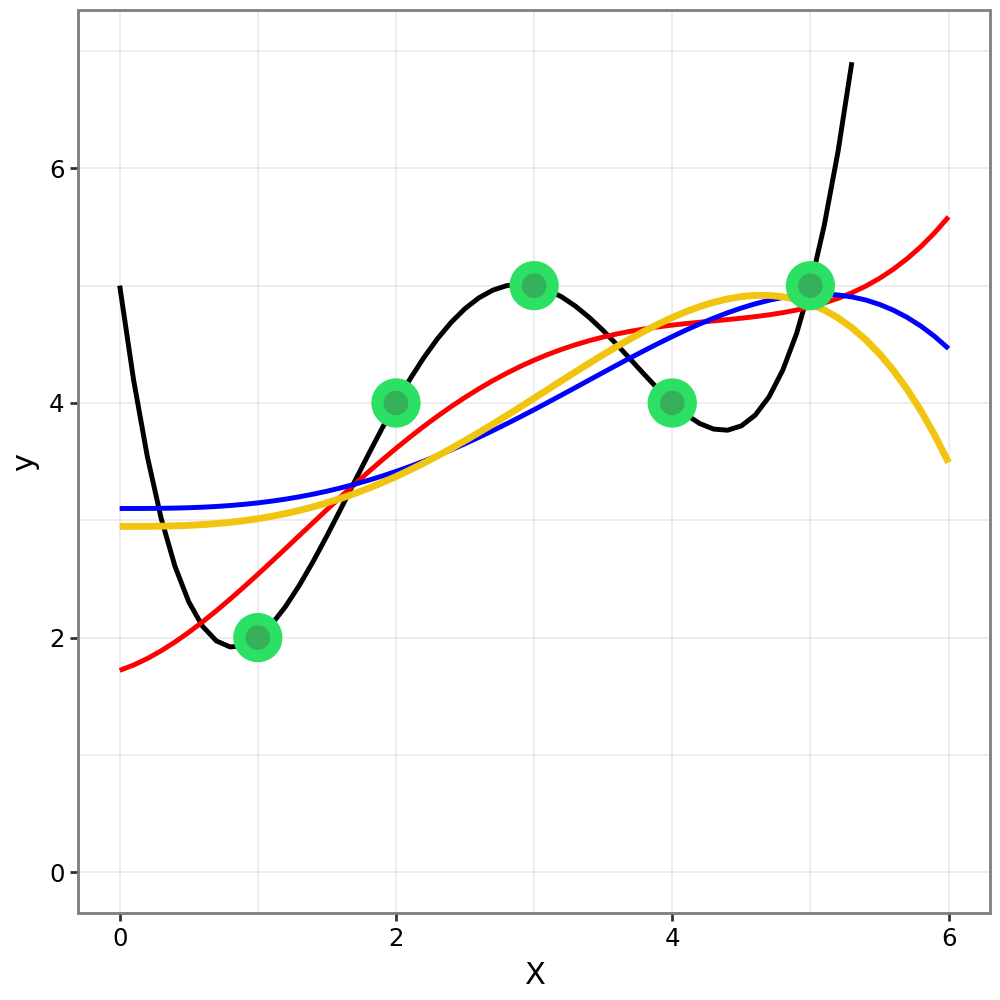

In [5]:
fig = (
    ggplot(data = example_data,
          mapping = aes(x = 'x', y = 'y')) +
       ##### YOUR CODE STARTS #####
       geom_path(data=visualisation_data, mapping=aes(x='x', y='lr_y'), colour='black', size=1.0) +
       geom_path(data=visualisation_data, mapping=aes(x='x', y='ridge_y'), colour='red', size=1.0) +
       geom_path(data=visualisation_data, mapping=aes(x='x', y='lasso_y'), colour='blue', size=1.0) +
       geom_path(data=visualisation_data, mapping=aes(x='x', y='elastic_net_y'), colour='#F1C40F', size=1.4) +
       ##### YOUR CODE ENDS #####
    geom_point(fill = '#36B059',
               size = 5.0,
               stroke = 2.5,
               colour = '#2BE062',
               shape = 'o') +
    labs(
        title ='',
        x = 'X',
        y = 'y',
    ) +
    xlim(0, 6) +
    ylim(0, 7) +
    theme_bw() +
    theme(figure_size = (5, 5),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black')) +
    guides(size = False)
)
fig


<font color='red'> **(Homework exercise 1- c)** Print out ElasticNet coefficients and intercept, compare it to coefficients and intercept of other regressions. Which one ElasticNet seems to be more similar to? Which parameter in `sklearn.ElasticNet` function is responsible for mixing of L1 and L2 regularisation? **(1 point)**. </font>

In [6]:
##### YOUR CODE STARTS #####
print(f'ElasticNet regression coefficients are: {elastic_net.coef_}')
print(f'ElasticNet regression intercept is: {elastic_net.intercept_}')
print(f'Linear regression coefficients are: {lr.coef_}, intercept is: {lr.intercept_}')
print(f'Ridge regression coefficients are: {ridge.coef_}, intercept is: {ridge.intercept_}')
print(f'Lasso regression coefficients are: {lasso.coef_}, intercept is: {lasso.intercept_}')
##### YOUR CODE ENDS #####

ElasticNet regression coefficients are: [ 0.          0.          0.07844547 -0.01265445]
ElasticNet regression intercept is: 2.9476950987588086
Linear regression coefficients are: [-8.75        7.79166667 -2.25        0.20833333], intercept is: 5.000000000001698
Ridge regression coefficients are: [ 0.3882215   0.61877466 -0.20687874  0.0184773 ], intercept is: 1.7205023752824715
Lasso regression coefficients are: [ 0.          0.          0.05608653 -0.00829621], intercept is: 3.1005045969631007


<font color='red'>ElasticNet is closer to Lasso here, because both keep only high-degree terms. The `l1_ratio` parameter controls the L1/L2 mix.</font>


## Homework exercise 2 (4 points): searching for good dropout rate
<font color='red'> Use `sklearn` function (`KFold`) for cross-validation to find the best possible dropout rate for the neural network we used in the class (that you call via `define_model_dropout`). </font>

In [7]:
# Keras comes with built-in loaders for common datasets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]

# Normalising values
mu = X_train.mean(axis=(0,1,2)) # finds mean of R, G and B separately
std = X_train.std(axis=(0,1,2)) # same for std
X_train_norm = (X_train - mu)/std
X_test_norm = (X_test - mu)/std

<font color='red'> **(Homework exercise 2- a)** Run cross-validation by filling in the gaps and collect validation accuracy scores for each dropout rate. **(2 points)**. </font>


In [8]:
from sklearn.model_selection import KFold
dropout_rates = [0.0, 0.1, 0.25, 0.5, 0.99] # feel free to choose other values to loop over

# you can collect both accuracy and loss if you like,
# but loss is influenced by the regularisation itself, so maybe less informative
val_fold_acc = np.zeros(len(dropout_rates))
val_fold_loss = np.zeros(len(dropout_rates))

for i, dropout_rate in enumerate(dropout_rates):
  print(f'Validation loss for dropout rate = {dropout_rate}...')
  ##### YOUR CODE STARTS #####
  # 4-fold cross validation
  # Here we are using sklearn Cross Validation Function called KFold
  kf = KFold(n_splits=4, shuffle=True, random_state=111)

  # Do not change these lines, we initialize empty lists
  fold_acc = []
  fold_loss = []
  cv_X = X_train_norm[:2000]
  cv_y = y_train[:2000]
  for train_index, val_index in kf.split(cv_X):

    # split data into train_X, train_y and val_X, val_y depending on the fold:
    train_X = cv_X[train_index]
    train_y = cv_y[train_index]
    val_X = cv_X[val_index]
    val_y = cv_y[val_index]

    # train the neural network with dropout_rate
    model = define_model_dropout(dropout_rate)

    # compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # fit the neural network on training data
    # number of epochs is tricky, if you choose too little the performance will be unstable
    # if you choose too large, it will take ages to complete...
    model.fit(train_X, train_y, epochs=1, batch_size=128, verbose=0)

    # calculate accuracy for this fold and store it in fold_acc
    loss, acc = model.evaluate(val_X, val_y, verbose=0)
    fold_acc.append(acc)

    # and loss in fold_loss
    fold_loss.append(loss)
    ##### YOUR CODE ENDS #####

  print(f'Average validation accuracy for {dropout_rate} is {np.mean(fold_acc)}')
  val_fold_acc[i] = np.mean(fold_acc)
  val_fold_loss[i] = np.mean(fold_loss)

Validation loss for dropout rate = 0.0...


Average validation accuracy for 0.0 is 0.23149999976158142
Validation loss for dropout rate = 0.1...


Average validation accuracy for 0.1 is 0.2289999984204769
Validation loss for dropout rate = 0.25...


Average validation accuracy for 0.25 is 0.18200000002980232
Validation loss for dropout rate = 0.5...


Average validation accuracy for 0.5 is 0.11950000189244747
Validation loss for dropout rate = 0.99...


Average validation accuracy for 0.99 is 0.09050000086426735


<font color='red'> **(Homework exercise 2- b)** Create a plot (using standard matplotlib) that shows validation accuracy and loss for different dropout rates that you have tried, report the best one. **(1 point)**. </font>


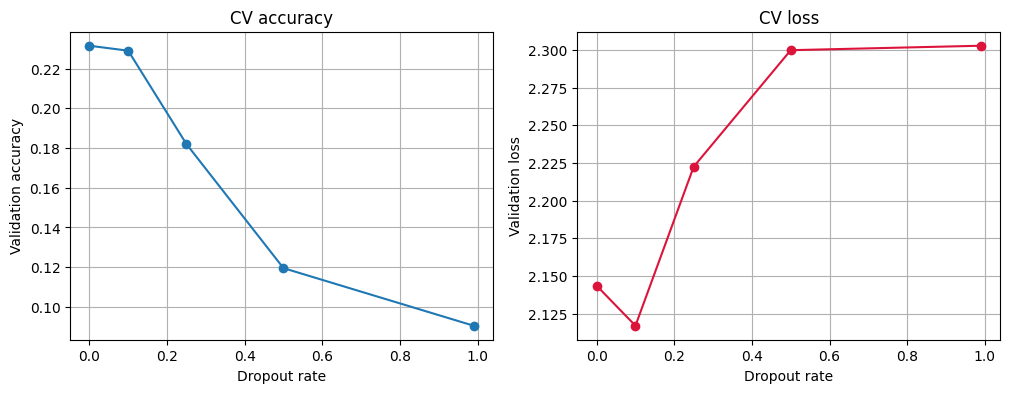

Best dropout rate by validation accuracy: 0.0


In [9]:
##### YOUR CODE STARTS #####
# Plot for accuracies
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(dropout_rates, val_fold_acc, marker='o')
plt.xlabel('Dropout rate')
plt.ylabel('Validation accuracy')
plt.title('CV accuracy')
plt.grid(True)

# Plot for losses
plt.subplot(1, 2, 2)
plt.plot(dropout_rates, val_fold_loss, marker='o', color='crimson')
plt.xlabel('Dropout rate')
plt.ylabel('Validation loss')
plt.title('CV loss')
plt.grid(True)
plt.show()

best_dropout_rate = dropout_rates[int(np.argmax(val_fold_acc))]
print(f'Best dropout rate by validation accuracy: {best_dropout_rate}')
##### YOUR CODE ENDS #####

According to the above graphs, the best dropout rate seems to be ...

<font color='red'> **(Homework exercise 2- c)** Re-train the network using the dropout rate reported in **(b)**. Visualise performance curves and interpret the results. (if results did not improve, no need to re-run the process again, just comment on the results). **(1 point)**. </font>

In [10]:
##### YOUR CODE STARTS #####
# Define the model with identified dropout rate and compile it
final_dropout_model = define_model_dropout(best_dropout_rate)
final_dropout_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Fit the model; return history object

history_dropout = final_dropout_model.fit(
    X_train_norm, y_train,
    epochs=2,
    batch_size=128,
    validation_split=0.1,
    verbose=0
)
print(f"Final validation accuracy: {history_dropout.history['val_accuracy'][-1]:.4f}")
##### YOUR CODE ENDS #####

Final validation accuracy: 0.5824


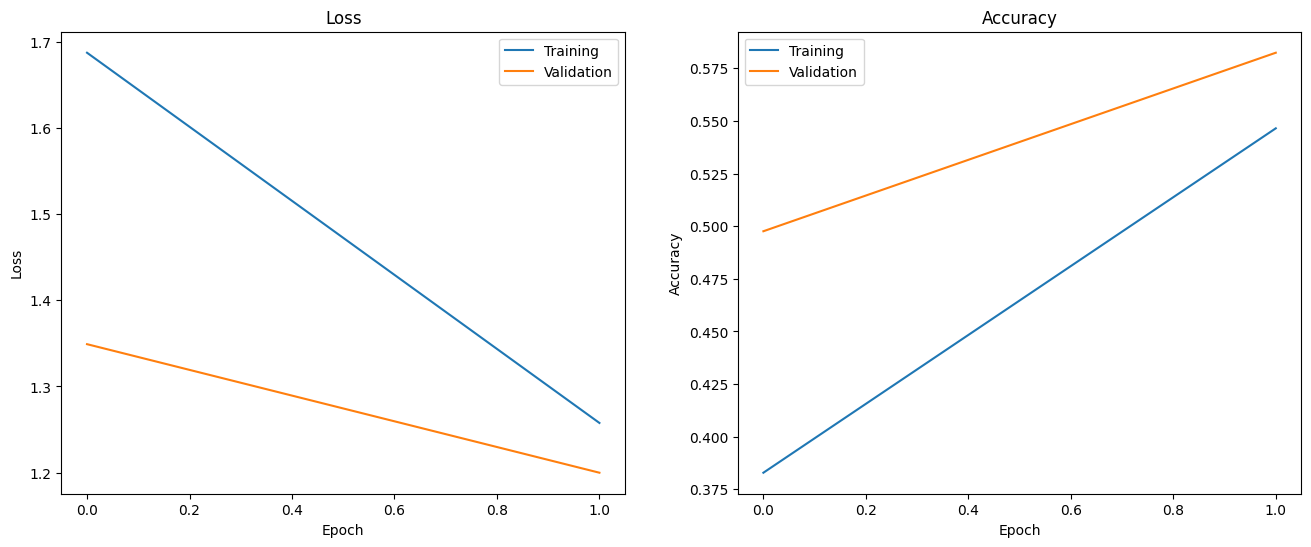

In [11]:
##### YOUR CODE STARTS #####
# plot the progress curves here
plot_curves(history_dropout)
plt.show()
##### YOUR CODE ENDS #####

In [12]:
##### YOUR CODE STARTS #####
# evaluate the model here
test_loss_dropout, test_acc_dropout = final_dropout_model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Test loss: {test_loss_dropout:.4f}')
print(f'Test accuracy: {test_acc_dropout:.4f}')

# Keras 3 compatibility for the template import used below.
import keras.preprocessing.image as keras_image
from tensorflow.keras.preprocessing.image import ImageDataGenerator as TFImageDataGenerator
keras_image.ImageDataGenerator = TFImageDataGenerator
##### YOUR CODE ENDS #####

Test loss: 1.2110
Test accuracy: 0.5755


<font color='red'>In this run dropout did not improve the score, so the best rate was 0.0. Strong dropout likely removed too much signal for this small training setup.</font>

...

## Homework exercise 3 (3 points): applying more sophisticated augmentation pipelines
<font color='red'> Check https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator and add more interesting transformation into the pipeline we have developed in the class. Train your network again, and interpret the results. First of all some setup. </font>

In [13]:
# Keras comes with built-in loaders for common datasets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]


<font color='red'> **(Homework exercise 3- a)** Add at least 2-3 more different transformations described at https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator. Augment CIFAR10 training images. Visualise a few random augmentated images (as we have done for the simple augmentation pipeline in the class). This time, make 5 by 5 grid instead of 3 by 3. Briefly explain your choice of augmentation pipeline (i.e. why these augmentation you added will help?). **(1 point)**. </font>


In [14]:
from keras.preprocessing.image import ImageDataGenerator

##### YOUR CODE STARTS #####
# Create your own data augmentation pipeline:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='reflect'
)
##### YOUR CODE ENDS #####

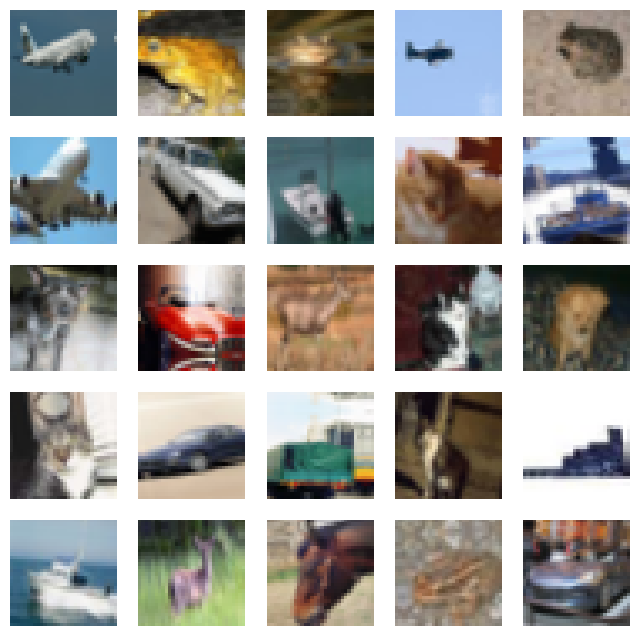

In [15]:
##### YOUR CODE STARTS #####
plt.rcParams['figure.figsize'] = (8.0, 8.0) # set default size of plots

# Configure batch size and retrieve one batch of images
for batch_X, batch_y in datagen.flow(X_train, y_train, batch_size=25, shuffle=True):
    # Show 25 images
    for j in range(25):
        plt.subplot(5, 5, j + 1)
        plt.imshow(np.clip(batch_X[j], 0, 255).astype('uint8'))
        plt.axis('off')
    # show the plot
    plt.show()
    break
##### YOUR CODE ENDS #####

<font color='red'> **(Homework exercise 3- b)** First, split the training data into train and validation sets using `train_test_split` function from `sklearn` (use 10% for validation). Then normalise each of the three sets (train, val and test) using mean and standard deviations computed on train images (for R, G and B separately). Finally, retrain the model using this new augmented training set. Use non-augmented normalised validation set for validation of the model while training. **(1.5 points)**. </font>

In [16]:
from sklearn.model_selection import train_test_split

##### YOUR CODE STARTS #####
# Split the training data further into train and val
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=111,
    stratify=y_train
)

mu = X_train_split.mean(axis=(0,1,2)) # finds mean of R, G and B separately
std = X_train_split.std(axis=(0,1,2)) # same for std
X_train_norm = (X_train_split - mu) / std
X_val_norm = (X_val - mu) / std
X_test_norm = (X_test - mu) / std
##### YOUR CODE ENDS #####

# Assign augmentation schema to X_train_norm
datagen.fit(X_train_norm)

In [17]:
##### YOUR CODE STARTS #####
# Create a model
# here you can use either model with dropout or L2 regularisation defined above
aug_model = define_model_dropout(best_dropout_rate if 'best_dropout_rate' in globals() else 0.25)

# Compile the model as before (code is identical)
aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# remember to use .fit() to train the model
# use batch_size 64 as in the class
history_aug = aug_model.fit(
    datagen.flow(X_train_norm, y_train_split, batch_size=64),
    steps_per_epoch=len(X_train_norm) // 64,
    epochs=2,
    validation_data=(X_val_norm, y_val),
    verbose=0
)
print(f"Augmented final validation accuracy: {history_aug.history['val_accuracy'][-1]:.4f}")
##### YOUR CODE ENDS #####

Augmented final validation accuracy: 0.4784



<font color='red'> **(Homework exercise 3- c)** Plot the performance curves (loss and accuracy), evaluate your model on the non-augmented normalised test set and interpret the results. Did the performance improve? Why? Why not? **(0.5 points)**. </font>

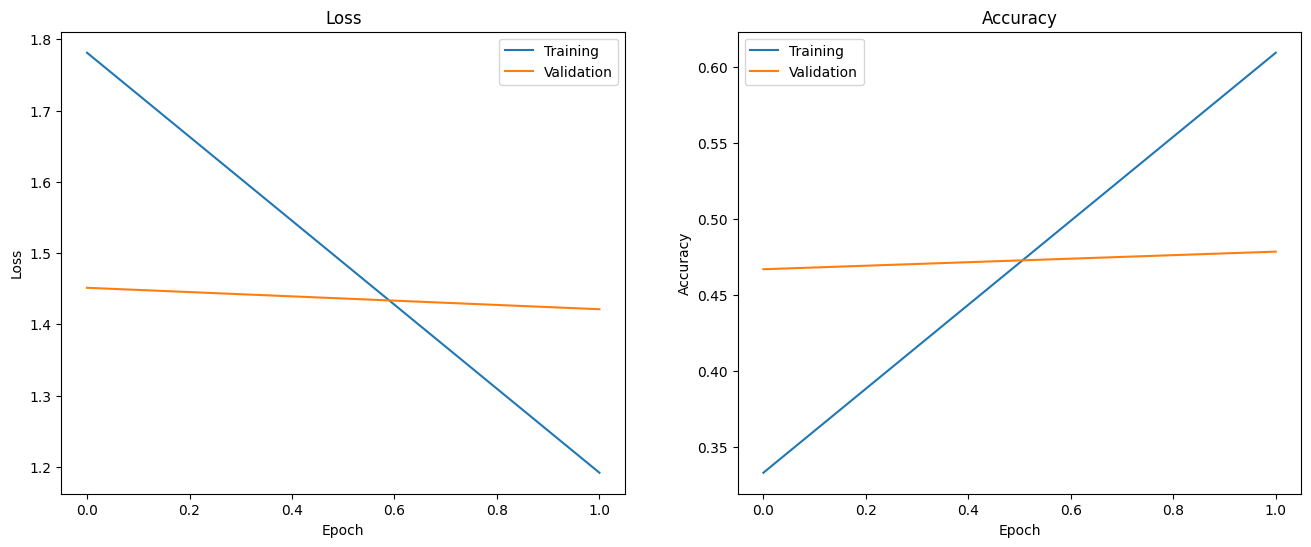

In [18]:
##### YOUR CODE STARTS #####
plot_curves(history_aug)
plt.show()
##### YOUR CODE ENDS #####

In [19]:
##### YOUR CODE STARTS #####
test_loss_aug, test_acc_aug = aug_model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Augmented model test loss: {test_loss_aug:.4f}')
print(f'Augmented model test accuracy: {test_acc_aug:.4f}')
##### YOUR CODE ENDS #####

Augmented model test loss: 1.3891
Augmented model test accuracy: 0.4853


<font color='red'>The augmented model did not improve in this short run. The transforms may be too strong for tiny CIFAR-10 images, and two epochs are not enough to fully benefit from augmentation.</font>

...

# Bonus exercises
*(NB, these are optional exercises!)*


## Bonus exercise 1 (2 points):

<font color='red'> Implement basic linear regression and Ridge regression using the closed form solutions (https://stats.stackexchange.com/questions/69205/how-to-derive-the-ridge-regression-solution). Run your implementations on the following synthetic dataset. Compare model coefficients to coefficients produced by `sklearn` functions `LinearRegression` and `Ridge`. Speculate about the difference in coefficients that you observe. </font>

In [20]:
# here we generate a synthetic dataset:
from sklearn.datasets import make_regression

X, y, coefficients = make_regression(
    n_samples=50,
    n_features=4,
    n_informative=1,
    n_targets=1,
    noise=5,
    coef=True,
    random_state=1
)

X.shape

(50, 4)

<font color='red'> Implement closed form solutions for both baseline linear regression and ridge regression (https://stats.stackexchange.com/questions/69205/how-to-derive-the-ridge-regression-solution) on the synthetic dataset: </font>



In [21]:
n, m = X.shape
I = np.identity(m)
lambda_ = 1

##### YOUR CODE STARTS #####
lambd = lambda_

# Implement baseline linear regression (closed form solution)
X_mean = X.mean(axis=0)
y_mean = y.mean()
X_centered = X - X_mean
y_centered = y - y_mean

lr_coef = np.linalg.pinv(X_centered.T @ X_centered) @ X_centered.T @ y_centered
lr_intercept = y_mean - X_mean @ lr_coef


# Implement Ridge regression (closed form solution)
lr_ridge_coef = np.linalg.solve(X_centered.T @ X_centered + lambda_ * I, X_centered.T @ y_centered)
lr_rigde_intercept = y_mean - X_mean @ lr_ridge_coef


##### YOUR CODE ENDS #####

In [22]:
from sklearn.linear_model import LinearRegression

# Initialise Linear Regression model from sklearn:
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
print(lr.coef_)
print(lr.intercept_)

[86.7933953   0.12444455  0.699363   -1.78601527]
-0.21031847531199954


In [24]:
from sklearn.linear_model import Ridge

lr_ridge = Ridge(lambd, solver='cholesky')
lr_ridge.fit(X, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'cholesky'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None

In [25]:
print(lr_ridge.coef_)
print(lr_ridge.intercept_)

[84.51986709 -0.59219469  0.22580939 -2.23109663]
0.14955471081851623


<font color='red'>  Compare coefficients you obtained using closed form solution and sklearn implementations. Comment on the difference you observe. </font>



In [26]:
##### YOUR CODE STARTS #####
print(f"Manually calculated linear W1 = {lr_coef}, W0 = {lr_intercept}")
print(f"Sklearn linear W1 = {lr.coef_}, W0 = {lr.intercept_}")
print(f"Manually calculated Ridge W1 = {lr_ridge_coef}, W0 = {lr_rigde_intercept}")
print(f"Sklearn Ridge W1 = {lr_ridge.coef_}, W0 = {lr_ridge.intercept_}")
##### YOUR CODE ENDS #####

Manually calculated linear W1 = [86.7933953   0.12444455  0.699363   -1.78601527], W0 = -0.21031847531206171
Sklearn linear W1 = [86.7933953   0.12444455  0.699363   -1.78601527], W0 = -0.21031847531199954
Manually calculated Ridge W1 = [84.51986709 -0.59219469  0.22580939 -2.23109663], W0 = 0.14955471081851446
Sklearn Ridge W1 = [84.51986709 -0.59219469  0.22580939 -2.23109663], W0 = 0.14955471081851623


<font color='red'>The manual and sklearn coefficients are almost identical. Tiny differences come from numerical precision and solver details.</font>


...

## Bonus exercise 2 (up to 4 bonus points depending on presentation):
<font color='red'> Experimentally verify if CutMix augmentation helps to improve the test score on CIFAR10 (not clear, as images are very tiny). Link to the CutMix paper: https://arxiv.org/abs/1905.04899. Show couple of examples of CutMix augmented images and your implementation along with performance curves and scores. Compare the results of CutMix augmented model and the model without data augmentation. </font>


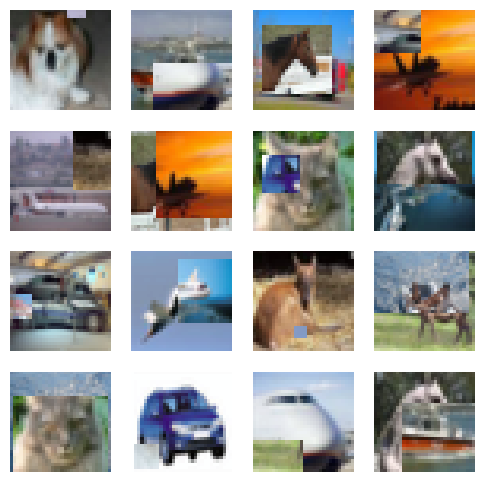

CutMix test loss: 1.8068
CutMix test accuracy: 0.3304


In [27]:
##### YOUR CODE STARTS #####
def sample_beta_distribution(size, concentration=1.0):
    gamma_1_sample = tf.random.gamma(shape=[size], alpha=concentration)
    gamma_2_sample = tf.random.gamma(shape=[size], alpha=concentration)
    return gamma_1_sample / (gamma_1_sample + gamma_2_sample)


def cutmix_batch(images, labels, alpha=1.0):
    batch_size = tf.shape(images)[0]
    image_h = tf.shape(images)[1]
    image_w = tf.shape(images)[2]
    labels = tf.one_hot(tf.cast(tf.squeeze(labels), tf.int32), 10)

    shuffled_indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_images = tf.gather(images, shuffled_indices)
    shuffled_labels = tf.gather(labels, shuffled_indices)

    lam = sample_beta_distribution(batch_size, alpha)
    cut_ratio = tf.sqrt(1.0 - lam)
    cut_w = tf.cast(tf.cast(image_w, tf.float32) * cut_ratio, tf.int32)
    cut_h = tf.cast(tf.cast(image_h, tf.float32) * cut_ratio, tf.int32)

    cx = tf.random.uniform([batch_size], 0, image_w, dtype=tf.int32)
    cy = tf.random.uniform([batch_size], 0, image_h, dtype=tf.int32)
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, image_w)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, image_h)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, image_w)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, image_h)

    masks = []
    for k in range(images.shape[0]):
        yy, xx = tf.meshgrid(tf.range(image_h), tf.range(image_w), indexing='ij')
        patch = (xx >= x1[k]) & (xx < x2[k]) & (yy >= y1[k]) & (yy < y2[k])
        masks.append(tf.cast(patch, images.dtype))
    mask = tf.expand_dims(tf.stack(masks), -1)

    mixed_images = images * (1.0 - mask) + shuffled_images * mask
    patch_area = tf.cast((x2 - x1) * (y2 - y1), tf.float32)
    lam_adjusted = 1.0 - patch_area / tf.cast(image_h * image_w, tf.float32)
    mixed_labels = labels * tf.expand_dims(lam_adjusted, 1) + shuffled_labels * tf.expand_dims(1.0 - lam_adjusted, 1)
    return mixed_images, mixed_labels

cutmix_train_X = X_train_norm[:4000].astype('float32')
cutmix_train_y = y_train_split[:4000]
cutmix_val = (X_val_norm[:2000].astype('float32'), tf.keras.utils.to_categorical(np.squeeze(y_val[:2000]), 10))
cutmix_test = (X_test_norm.astype('float32'), tf.keras.utils.to_categorical(np.squeeze(y_test), 10))

preview_images, preview_labels = cutmix_batch(tf.constant(cutmix_train_X[:16]), tf.constant(cutmix_train_y[:16]))
plt.figure(figsize=(6, 6))
for j in range(16):
    plt.subplot(4, 4, j + 1)
    image = preview_images[j].numpy() * std + mu
    plt.imshow(np.clip(image, 0, 255).astype('uint8'))
    plt.axis('off')
plt.show()

cutmix_ds = (
    tf.data.Dataset.from_tensor_slices((cutmix_train_X, cutmix_train_y))
    .shuffle(4000, seed=111)
    .batch(64, drop_remainder=True)
    .map(lambda x, y: cutmix_batch(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

cutmix_model = define_model_dropout(best_dropout_rate if 'best_dropout_rate' in globals() else 0.25)
cutmix_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_cutmix = cutmix_model.fit(cutmix_ds, epochs=2, validation_data=cutmix_val, verbose=0)
cutmix_loss, cutmix_acc = cutmix_model.evaluate(*cutmix_test, verbose=0)
print(f'CutMix test loss: {cutmix_loss:.4f}')
print(f'CutMix test accuracy: {cutmix_acc:.4f}')
##### YOUR CODE ENDS #####

No augmentation test loss: 1.5614
No augmentation test accuracy: 0.4194
CutMix test accuracy: 0.3304


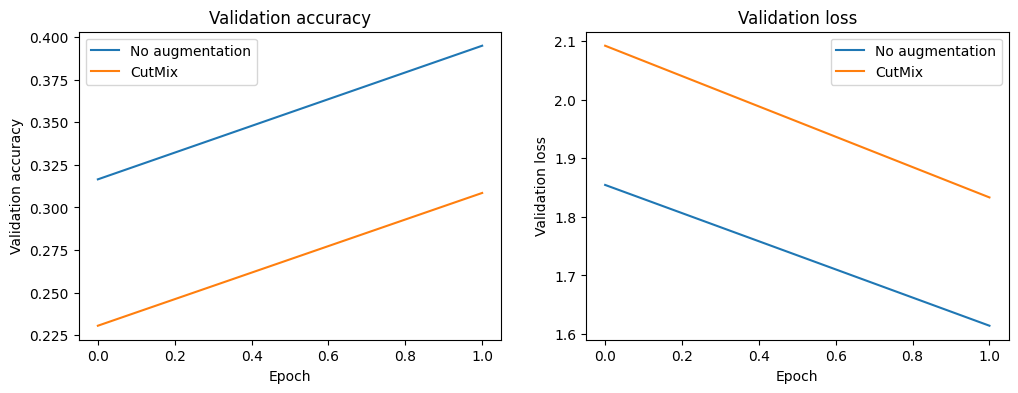

In [28]:
#Comparison part
##### YOUR CODE STARTS #####
baseline_train_y = tf.keras.utils.to_categorical(np.squeeze(cutmix_train_y), 10)

baseline_model = define_model_dropout(best_dropout_rate if 'best_dropout_rate' in globals() else 0.25)
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_no_aug_bonus = baseline_model.fit(
    cutmix_train_X,
    baseline_train_y,
    epochs=2,
    batch_size=64,
    validation_data=cutmix_val,
    verbose=0
)
baseline_loss, baseline_acc = baseline_model.evaluate(*cutmix_test, verbose=0)
print(f'No augmentation test loss: {baseline_loss:.4f}')
print(f'No augmentation test accuracy: {baseline_acc:.4f}')
print(f'CutMix test accuracy: {cutmix_acc:.4f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_no_aug_bonus.history['val_accuracy'], label='No augmentation')
plt.plot(history_cutmix.history['val_accuracy'], label='CutMix')
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.legend()
plt.title('Validation accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_no_aug_bonus.history['val_loss'], label='No augmentation')
plt.plot(history_cutmix.history['val_loss'], label='CutMix')
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.legend()
plt.title('Validation loss')
plt.show()
##### YOUR CODE ENDS #####

<font color='red'>CutMix did not improve the score in this experiment. On CIFAR-10, mixed patches can hide the main object, and the short training run favors the simpler baseline.</font>

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you send on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us